### **pix2pix GAN Qualitative Evaluation**

This notebook visualizes the qualitative performance of a **fully trained pix2pix conditional GAN**, where the generator is trained jointly with a **PatchGAN discriminator** using a combination of **adversarial loss** and **L1 reconstruction loss**.

Using a small batch of samples from the **validation set**, we:

* Load trained **pix2pix generator checkpoints** produced by the full training pipeline
* Generate map images conditioned on satellite inputs
* Compare **satellite input → generated output → ground truth map** side by side

The goal of this notebook is **qualitative evaluation and model inspection** after full adversarial training.
It allows us to assess improvements in **sharpness, local structure, and realism** introduced by the discriminator compared to the baseline model.

No training is performed in this notebook.

The **validation set** is used intentionally to prevent data leakage, and the **test set is strictly reserved** for final, unbiased evaluation.



In [1]:
import os, sys

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

print("Project root:", root_dir)

Project root: c:\Users\NoteBook\Desktop\programing\Computer Vision\satellite-to-map-image-translation-gan


In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from utils.dataloader import get_dataloader, transform
from models.generator import GeneratorUNet

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 5
CHECKPOINT_PATH = os.path.join(root_dir, os.path.join("results","checkpoints","cgan","generator_best.pth"))

data_dir = os.path.join(root_dir, 'data', 'processed')

In [4]:
val_loader = get_dataloader(
    data_dir=data_dir,
    split='val',
    batch_size=BATCH_SIZE,
    shuffle=False,
    transform=transform
)

sat_images, gt_maps = next(iter(val_loader))
sat_images = sat_images.to(device)
gt_maps = gt_maps.to(device)


In [5]:
generator = GeneratorUNet().to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
generator.load_state_dict(checkpoint["model_state_dict"])
generator.eval()


C:\Users\NoteBook\AppData\Local\Temp\ipykernel_2008\1840417423.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=devi

GeneratorUNet(
  (down1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (down2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (down3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (down4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), paddi

In [6]:
with torch.no_grad():
    fake_maps = generator(sat_images)


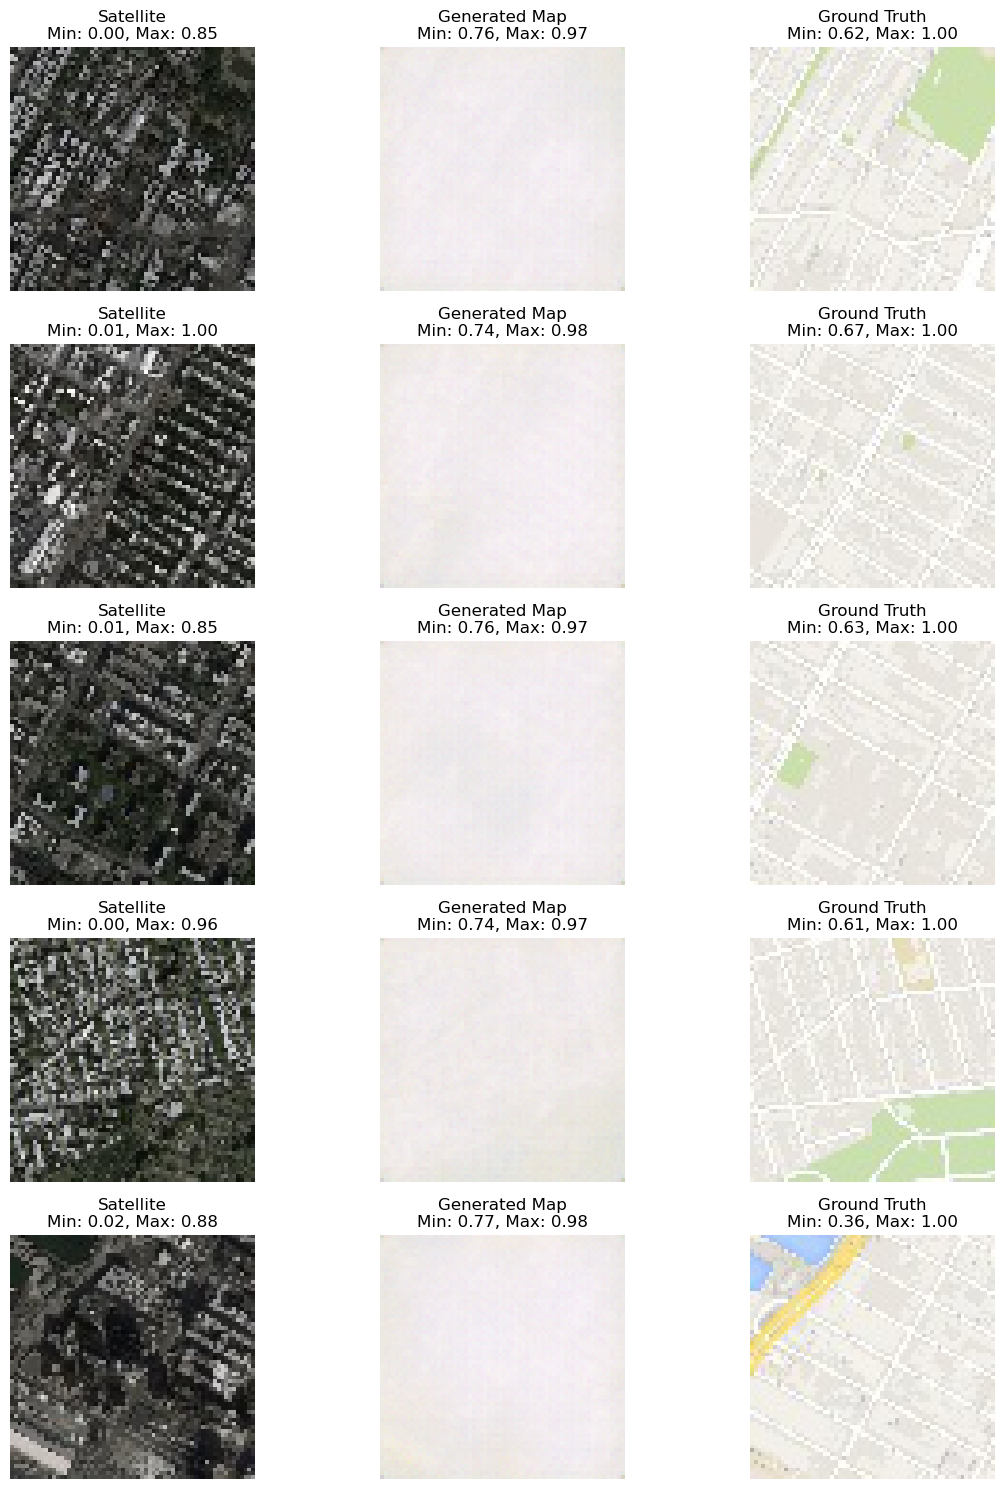

In [7]:
def denormalize(tensor, mean=0.5, std=0.5):
    """Convert from [-1, 1] to [0, 1] range for display."""
    return tensor * std + mean

def show_triplets(sat, fake, gt, n=5):
    sat = sat[:n].cpu()
    fake = fake[:n].cpu()
    gt = gt[:n].cpu()
    
    # Denormalize from [-1, 1] to [0, 1]
    sat = denormalize(sat)
    fake = denormalize(fake)
    gt = denormalize(gt)
    
    # Clamp to valid range [0, 1] for display
    sat = torch.clamp(sat, 0, 1)
    fake = torch.clamp(fake, 0, 1)
    gt = torch.clamp(gt, 0, 1)
    
    fig, axes = plt.subplots(n, 3, figsize=(12, 3*n))
    
    for i in range(n):
        # Satellite (should be RGB)
        axes[i, 0].imshow(sat[i].permute(1, 2, 0))
        axes[i, 0].set_title(f"Satellite\nMin: {sat[i].min():.2f}, Max: {sat[i].max():.2f}")
        axes[i, 0].axis("off")
        
        # Generated map
        axes[i, 1].imshow(fake[i].permute(1, 2, 0))
        axes[i, 1].set_title(f"Generated Map\nMin: {fake[i].min():.2f}, Max: {fake[i].max():.2f}")
        axes[i, 1].axis("off")
        
        # Ground truth map
        axes[i, 2].imshow(gt[i].permute(1, 2, 0))
        axes[i, 2].set_title(f"Ground Truth\nMin: {gt[i].min():.2f}, Max: {gt[i].max():.2f}")
        axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Also add a diagnostic function
def check_image_stats(images, title="Images"):
    """Check if images are truly RGB or appear grayscale."""
    print(f"\n{'='*60}")
    print(f"Checking: {title}")
    print(f"{'='*60}")
    
    # Check if all 3 channels are different (RGB) or same (grayscale)
    for i in range(min(3, len(images))):  # Check first 3
        img = images[i].cpu()
        
        # Calculate channel means
        r_mean = img[0].mean().item()
        g_mean = img[1].mean().item()
        b_mean = img[2].mean().item()
        
        # Calculate differences between channels
        diff_rg = abs(r_mean - g_mean)
        diff_rb = abs(r_mean - b_mean)
        
        print(f"Image {i}:")
        print(f"  Range: [{img.min():.3f}, {img.max():.3f}]")
        print(f"  Channel means: R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}")
        print(f"  Channel diffs: R-G={diff_rg:.3f}, R-B={diff_rb:.3f}")
        
        if diff_rg < 0.01 and diff_rb < 0.01:
            print(f"  ⚠️  Warning: Channels nearly identical - appears grayscale!")
        else:
            print(f"  ✓ Channels differ - appears RGB")
    
    # Visualize channels separately
    if len(images) > 0:
        img = images[0].cpu()
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        
        # RGB composite
        axes[0].imshow(denormalize(img).permute(1, 2, 0))
        axes[0].set_title("RGB Composite")
        axes[0].axis('off')
        
        # Individual channels
        for j, (channel, color) in enumerate(zip(['Red', 'Green', 'Blue'], ['Reds', 'Greens', 'Blues'])):
            axes[j+1].imshow(denormalize(img[j]), cmap=color)
            axes[j+1].set_title(f"{channel} Channel\nMean: {img[j].mean():.3f}")
            axes[j+1].axis('off')
        
        plt.tight_layout()
        plt.show()

# def show_triplets(sat, fake, gt, n=5):
#     sat = sat[:n]
#     fake = fake[:n]
#     gt = gt[:n]

#     fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))

#     for i in range(n):
#         axes[i, 0].imshow(sat[i].permute(1,2,0).cpu())
#         axes[i, 0].set_title("Satellite")
#         axes[i, 0].axis("off")

#         axes[i, 1].imshow(fake[i].permute(1,2,0).cpu())
#         axes[i, 1].set_title("Generator Output")
#         axes[i, 1].axis("off")

#         axes[i, 2].imshow(gt[i].permute(1,2,0).cpu())
#         axes[i, 2].set_title("Ground Truth")
#         axes[i, 2].axis("off")

#     plt.tight_layout()
#     plt.show()


show_triplets(sat_images, fake_maps, gt_maps, n=5)
